In [1]:
import orcapod as op
from demo_setup.config import (
    namespace_lookup,
    data_dir,
    store_dir,
    client,
    active_agent,
)
import demo_setup.util as demo_util

## Orcapod DEMO

A framework for fully traceable and reproducible scientific computation

## Guiding Principles

- Reproducibility
- Performance
- Simplicity
- Flexibility
- Extensibility
- Reusability
- Robustness


## Monitors


In [2]:
# monitor active containers

# watch -n 0.5 docker ps -a

## Setup test inputs


- `data_lake/brain_mri`: Brain MRI slices used as input



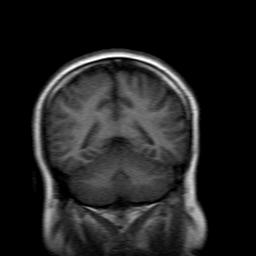
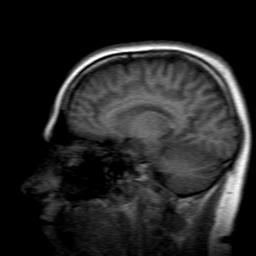
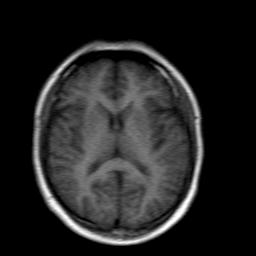

In [3]:
demo_util.display_jpegs("data_lake/brain_mri")

## Define computation


`segment_pod` : Python computation that:

- Applies a random delay between 5-10 seconds
- Reads a 2D brain MRI slice
- Normalizes image intensities
- Segments the slice into four intensity-based regions
  (background / CSF-like / gray-matter-like / bright tissue)
- Saves the image layers as a mask numpy array


In [4]:
from textwrap import dedent

In [5]:
segment_pod = op.Pod(
    image="maclucky/bambulab-timelapse-downloader:1.0.9",
    command=[
        "sh",
        "-c",
        "umask u=rwx,g=rwx,o=rwx && python -c '{}'".format(
            dedent(
                """
                from pathlib import Path
                from PIL import Image
                import numpy as np
                from time import sleep
                import random


                def configure_runtime():
                    sleep(random.choice([3, 5, 10]))


                def setup_io():
                    return {
                        "input_path": Path("/input/subject.jpeg"),
                        "output_path": Path("/output/mask.npy"),
                    }


                def segment(subject_image_path):
                    # Normalize intensity to [0, 1]
                    normalized_image = (
                        np.array(Image.open(subject_image_path).convert("L")).astype("float32") / 255.0
                    )

                    # Threshold-based segmentation into 4 intensity classes
                    mask = np.zeros_like(normalized_image, dtype=np.uint8)
                    mask[normalized_image < 0.05] = 0
                    mask[(normalized_image >= 0.05) & (normalized_image < 0.25)] = 1
                    mask[(normalized_image >= 0.25) & (normalized_image < 0.6)] = 2
                    mask[normalized_image >= 0.6] = 3

                    return mask


                configure_runtime()
                io_config = setup_io()
                np.save(io_config["output_path"], segment(io_config["input_path"]))

                print("done")
                """
            ).strip()
        ),
    ],
    input_spec={
        "subject_image": op.PathInfo(
            path="/input/subject.jpeg",
            match_pattern=r".*\.jpeg$",
        ),
    },
    output_dir="/output/",
    output_spec={
        "mask": op.PathInfo(path="mask.npy", match_pattern=r".*"),
    },
    source_commit_url="https://place.holder",
    recommended_cpus=1.0,
    recommended_memory=1 << 30,
)

`overlay_pod` : Python computation that:

- Applies a random delay between 0-5 seconds
- Reads the numpy array of the image layers
- Applies a fixed, colorblind-friendly color palette
- Generates the final overlay visualization

In [6]:
overlay_pod = op.Pod(
    image="maclucky/bambulab-timelapse-downloader:1.0.9",
    command=[
        "sh",
        "-c",
        "umask u=rwx,g=rwx,o=rwx && python -c '{}'".format(
            dedent(
                """
                from pathlib import Path
                from PIL import Image
                import numpy as np


                def setup_io():
                    return {
                        "input_path": Path("/input/mask.npy"),
                        "output_configs": {
                            Path("/output/overlay_image.png"): [
                                [0, 0, 0],       # 0, black,   background
                                [0, 114, 178],   # 1, blue,    CSF-like
                                [240, 228, 66],  # 2, yellow,  gray-matter-like
                                [255, 0, 0],     # 3, red,     bright tissue / skull-like
                            ]
                        },
                    }


                def save_overlay(mask, overlay_image_path, overlay_rgb_config):
                    # Create overlay for visualization
                    palette = np.array(overlay_rgb_config, dtype=np.uint8)
                    overlay_image = palette[mask]

                    Image.fromarray(overlay_image).save(overlay_image_path, quality=95)


                io_config = setup_io()
                mask = np.load(io_config["input_path"])
                for output_path, output_config in io_config["output_configs"].items():
                    save_overlay(mask, output_path, output_config)

                print("done")
                """
            ).strip()
        ),
    ],
    input_spec={
        "mask": op.PathInfo(path="/input/mask.npy", match_pattern=r".*"),
    },
    output_dir="/output/",
    output_spec={
        "overlay_image": op.PathInfo(
            path="overlay_image.png", match_pattern=r".*\.png$"
        ),
    },
    source_commit_url="https://place.holder",
    recommended_cpus=1.0,
    recommended_memory=1 << 30,
)

## Define computational pipeline


A simple compute pipeline that chains a `segment_pod` computation to a `overlay_pod` computation.

In [7]:
pipeline = op.Pipeline(
    graph_dot="""
    digraph {
        segment -> overlay
    }
    """,
    metadata={
        "segment": op.Kernel.POD(ref=segment_pod),
        "overlay": op.Kernel.POD(ref=overlay_pod),
    },
    input_spec={
        "subject_image": [op.InputSpecUri(node="segment", key="subject_image")],
    },
    output_spec={
        "overlay_image": op.OutputSpecUri(node="overlay", key="overlay_image"),
    },
)

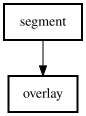

In [8]:
demo_util.display_dot(dot_data=pipeline.make_dot())

## Run computational pipeline job


In [9]:
from datetime import datetime, timezone

In [10]:
pipeline_job = op.PipelineJob(
    pipeline=pipeline,
    input_packet={
        "subject_image": [
            op.PathSet.UNARY(
                blob=op.Blob(
                    kind=op.BlobKind.FILE,
                    location=op.Uri(namespace="default", path=path),
                    checksum="",
                )
            )
            for path in (
                "brain_mri/axial.jpeg",
                "brain_mri/coronal.jpeg",
                "brain_mri/sagittal.jpeg",
            )
        ],
    },
    output_dir=op.Uri(
        namespace="default", path=f"{data_dir}/brain_segmentation_pipeline"
    ),
    namespace_lookup=namespace_lookup,
)

In [11]:
pipeline_run = await client.start_pipeline_job(pipeline_job=pipeline_job)

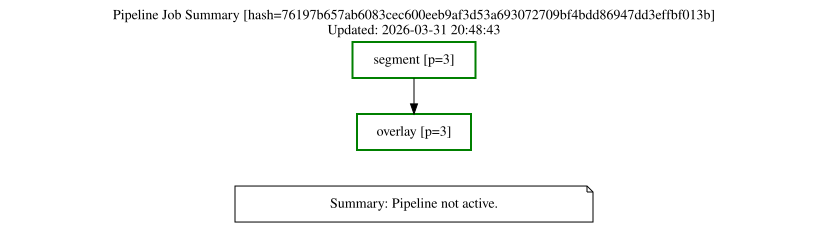

In [12]:
demo_util.animate_display(
    next_display_object=lambda: (
        demo_util.display_dot(dot_data=pipeline_run.summarize_dot())
        if not pipeline_run.terminated()
        or datetime.now(timezone.utc).timestamp() <= pipeline_run.terminated() + 2
        else None
    )
)

In [13]:
pipeline_result = await client.get_pipeline_result(pipeline_run=pipeline_run)

In [14]:
{
    "created": pipeline_result.created,
    "status": pipeline_result.status,
    "terminated": pipeline_result.terminated,
}

{'created': 1774990108,
 'status': <PipelineStatus.COMPLETED: 0>,
 'terminated': 1774990122}


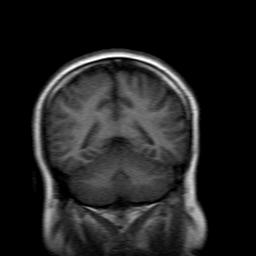
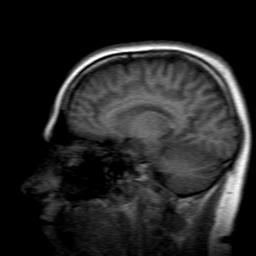
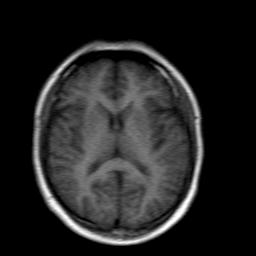


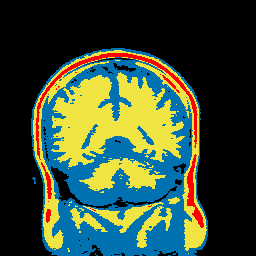
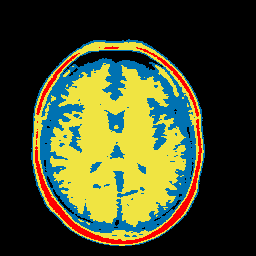
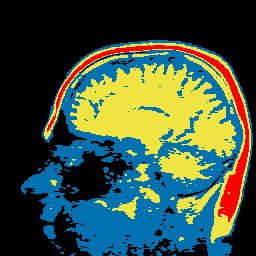

In [15]:
demo_util.display_jpegs("data_lake/brain_mri")
demo_util.display_jpegs("data_lake/data/brain_segmentation_pipeline/overlay")

## Roadmap

- Educational / Pitching Content
- Simpler, python-friendly experience
- Pipeline of pipelines
- Kubernetes orchestrator
- Queries and data exploration
- Dashboard GUIs
- Multi-agent support
- Tags
- Memoization
- Filter operator
- Agent resource limits
- Support external extensibility


## Teardown


In [16]:
import shutil
from pathlib import Path

In [17]:
shutil.rmtree(Path(namespace_lookup["default"]) / data_dir)
shutil.rmtree(Path(namespace_lookup["default"]) / store_dir)

In [18]:
active_agent.cancel()

True